In [7]:
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, accuracy_score


In [8]:
# Load the uploaded Excel file to examine its structure
file_path = "all_actions.xlsx"
xls = pd.ExcelFile(file_path)

# Display sheet names
sheet_names = xls.sheet_names

# Load the first sheet to examine the structure
df = xls.parse(sheet_names[0])
df.head()


,Unnamed: 0,SAC,PPO,GRPO,best_strategy
0,2019-01-02,max_sharpe,risk_parity,risk_parity,risk_parity
1,2019-01-31,max_sharpe,risk_parity,risk_parity,risk_parity
2,2019-03-01,max_sharpe,risk_parity,risk_parity,risk_parity
3,2019-03-29,max_sharpe,risk_parity,risk_parity,risk_parity
4,2019-04-29,max_sharpe,risk_parity,risk_parity,min_var


In [9]:
rename_col = {"risk_parity" : "Risk Parity",
 "min_var" : "Min Var",
 "max_sharpe" : "Max Sharpe",
 "paa" : "PAA"
}

In [10]:
df.columns

Index(['Unnamed: 0', 'SAC', 'PPO', 'GRPO', 'best_strategy'], dtype='object')

In [11]:
df[['SAC', 'PPO', 'GRPO', 'best_strategy']] = df[['SAC', 'PPO', 'GRPO', 'best_strategy']].apply(lambda x: x.map(rename_col))

In [12]:
df

,Unnamed: 0,SAC,PPO,GRPO,best_strategy
0,2019-01-02,Max Sharpe,Risk Parity,Risk Parity,Risk Parity
1,2019-01-31,Max Sharpe,Risk Parity,Risk Parity,Risk Parity
2,2019-03-01,Max Sharpe,Risk Parity,Risk Parity,Risk Parity
3,2019-03-29,Max Sharpe,Risk Parity,Risk Parity,Risk Parity
4,2019-04-29,Max Sharpe,Risk Parity,Risk Parity,Min Var
...,...,...,...,...,...
375,2024-08-23,PAA,Risk Parity,Max Sharpe,Min Var
376,2024-09-23,PAA,PAA,Max Sharpe,PAA
377,2024-10-21,PAA,Risk Parity,Max Sharpe,PAA
378,2024-11-18,PAA,Risk Parity,Max Sharpe,PAA


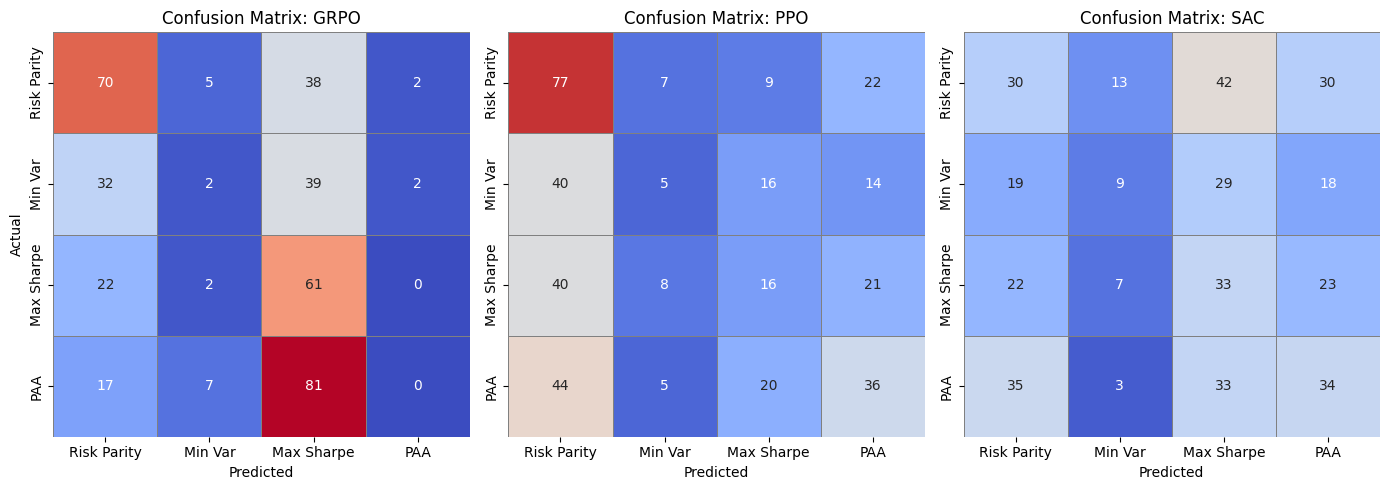

In [13]:
true_labels = df['best_strategy']
algorithms = ["GRPO", 'PPO', 'SAC']

# 모든 confusion matrix 생성 후 최대값 계산
cms = []
max_val = 0
for algo in algorithms:
    preds = df[algo]
    cm = confusion_matrix(true_labels, preds, labels=true_labels.unique())
    cms.append(cm)
    max_val = max(max_val, cm.max())

# plot
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, algo in enumerate(algorithms):
    sns.heatmap(cms[i], annot=True, fmt='d',
                xticklabels=true_labels.unique(),
                yticklabels=true_labels.unique(),
                ax=axes[i], cmap="coolwarm", cbar=False,
                linewidths=0.5, linecolor='gray',
                vmin=0, vmax=max_val)  # 동일한 색상 범위 적용
    axes[i].set_title(f'Confusion Matrix: {algo}')
    axes[i].set_xlabel('Predicted')
    if i == 0:
        axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig("/workspace/figure/confusion_matrix.png", dpi=600, bbox_inches='tight')
plt.show()

In [14]:

# Initialize storage for performance reports
reports = {}

# Get sorted list of labels for consistency
labels = sorted(df['best_strategy'].unique())

# Compute classification report for each model
for algo in algorithms:
    y_true = df['best_strategy']
    y_pred = df[algo]
    report = classification_report(y_true, y_pred, labels=labels, output_dict=True, zero_division=0)
    overall_accuracy = accuracy_score(y_true, y_pred)
    reports[algo] = {
        'accuracy': overall_accuracy,
        'macro avg': report['macro avg'],
        'weighted avg': report['weighted avg']
    }

# Create summary DataFrame
summary_df = pd.DataFrame({
    model: {
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Macro Precision': f"{metrics['macro avg']['precision']:.4f}",
        'Macro Recall': f"{metrics['macro avg']['recall']:.4f}",
        'Macro F1-Score': f"{metrics['macro avg']['f1-score']:.4f}",
        'Weighted Precision': f"{metrics['weighted avg']['precision']:.4f}",
        'Weighted Recall': f"{metrics['weighted avg']['recall']:.4f}",
        'Weighted F1-Score': f"{metrics['weighted avg']['f1-score']:.4f}"
    }
    for model, metrics in reports.items()
}).T


In [15]:
summary_df

,Accuracy,Macro Precision,Macro Recall,Macro F1-Score,Weighted Precision,Weighted Recall,Weighted F1-Score
GRPO,0.3500,0.2250,0.3383,0.2480,0.2372,0.3500,0.2639
PPO,0.3526,0.3081,0.3168,0.2925,0.3210,0.3526,0.3167
SAC,0.2789,0.2822,0.2732,0.2652,0.2845,0.2789,0.2713


In [17]:
def calculate_strategy_match(df, date_col='Unnamed: 0', best_col='best_strategy', 
                             model_cols=['SAC', 'PPO', 'GRPO']):
    """
    각 모델의 전략이 best_strategy와 일치하는지 계산
    
    Returns:
        match_df : DataFrame (1: 일치, 0: 불일치)
    """
    data = df.copy()
    
    if date_col in data.columns:
        data = data.set_index(date_col)
    
    match_df = pd.DataFrame(index=data.index)
    
    for model in model_cols:
        match_df[model] = (data[model] == data[best_col]).astype(int)
    
    return match_df

In [18]:
match_df = calculate_strategy_match(
    df=df,
    date_col='Unnamed: 0',
    best_col='best_strategy',
    model_cols=['SAC', 'PPO', 'GRPO']
)

In [36]:
match_count = match_df.groupby(match_df.index).sum()


In [41]:
match_count.index.name = 'Date'
df_melt = match_count.reset_index().melt(id_vars='Date', 
                                         var_name='Model', 
                                         value_name='Match Count')

In [42]:
df_melt

,Date,Model,Match Count
0,2019-01-02,SAC,1
1,2019-01-31,SAC,1
2,2019-03-01,SAC,1
3,2019-03-29,SAC,1
4,2019-04-29,SAC,1
...,...,...,...
223,2024-08-23,GRPO,0
224,2024-09-23,GRPO,0
225,2024-10-21,GRPO,0
226,2024-11-18,GRPO,0


In [52]:
# melt → pivot으로 변환
heatmap_data = df_melt.pivot(index='Model', columns='Date', values='Match Count')
heatmap_data.columns = pd.to_datetime(heatmap_data.columns)


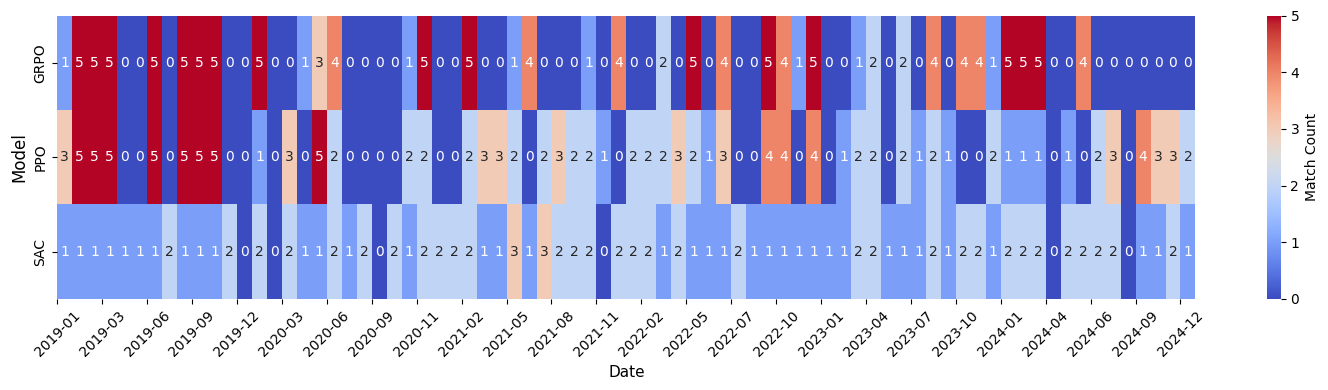

In [75]:
plt.figure(figsize=(15, 4))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', 
            cbar_kws={'label': 'Match Count'}, linewidths=0, fmt='g')

# 'YYYY-MM-DD' → 'YYYY-MM'로 축약해서 표시
month_labels = [str(d)[:7] for d in heatmap_data.columns]

# 3개 간격으로만 표시
step = 3
plt.xticks(
    ticks=range(0, len(month_labels), step),
    labels=month_labels[::step],
    rotation=45,
    fontsize=10
)
plt.yticks(fontsize=10)
plt.ylabel('Model', fontsize=12)
plt.xlabel('Date', fontsize=11)
plt.tight_layout()
plt.savefig("/workspace/figure/strategy_selection_bar_chart.png", dpi=600, bbox_inches='tight')
plt.show()
